# Image Data Augmentation Techniques
## *Técnicas de aumentación de imágenes*

In [99]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import gc

## Configuration of Variables and functions
### *Configuración de variables y funciones*

In [100]:
imgPath = "/mnt/datos_compartidos/PortafolioProyectos/imgsPruebas/image2.png"

fontTitle = 16

In [101]:
def comparisonGraphic(imgOriginal, imgCompare, titleOriginal = "", titleCompare = "", saveImg = False, saveName = "imgComparison.pdf"):  # Define function to show 2 images side by side / Definir función para mostrar 2 imágenes lado a lado
    plt.figure(figsize=(10, 10))  # Create new figure with size 10x10 / Crear nueva figura con tamaño 10x10
    if imgCompare is not None:  # If there is a second image to compare / Si hay una segunda imagen para comparar
        plt.subplot(1, 2, 1)  # Create first subplot (1 row, 2 cols, pos 1) / Crear primer subplot (1 fila, 2 cols, pos 1)
    plt.imshow(imgOriginal)  # Display original image / Mostrar imagen original
    plt.title(titleOriginal, fontsize=fontTitle)  # Set title with title font size / Establecer título con tamaño de fuente de título
    plt.axis('off')  # Hide axes / Ocultar ejes

    if imgCompare is not None:  # If there is a second image / Si hay una segunda imagen
        plt.subplot(1, 2, 2)  # Create second subplot (1 row, 2 cols, pos 2) / Crear segundo subplot (1 fila, 2 cols, pos 2)
        plt.imshow(imgCompare)  # Display comparison image / Mostrar imagen de comparación
        plt.title(titleCompare, fontsize=fontTitle)  # Set title with title font size / Establecer título con tamaño de fuente de título
        plt.axis('off')  # Hide axes / Ocultar ejes

    plt.tight_layout()  # Adjust layout to prevent overlap / Ajustar diseño para evitar superposición
    if saveImg:  # If saving is enabled / Si guardar está habilitado
        plt.savefig(saveName, dpi=300, bbox_inches='tight')  # Save figure at 300 DPI / Guardar figura a 300 DPI
    plt.show()  # Show the figure / Mostrar la figura

## Show image
### *Mostrar imagen*

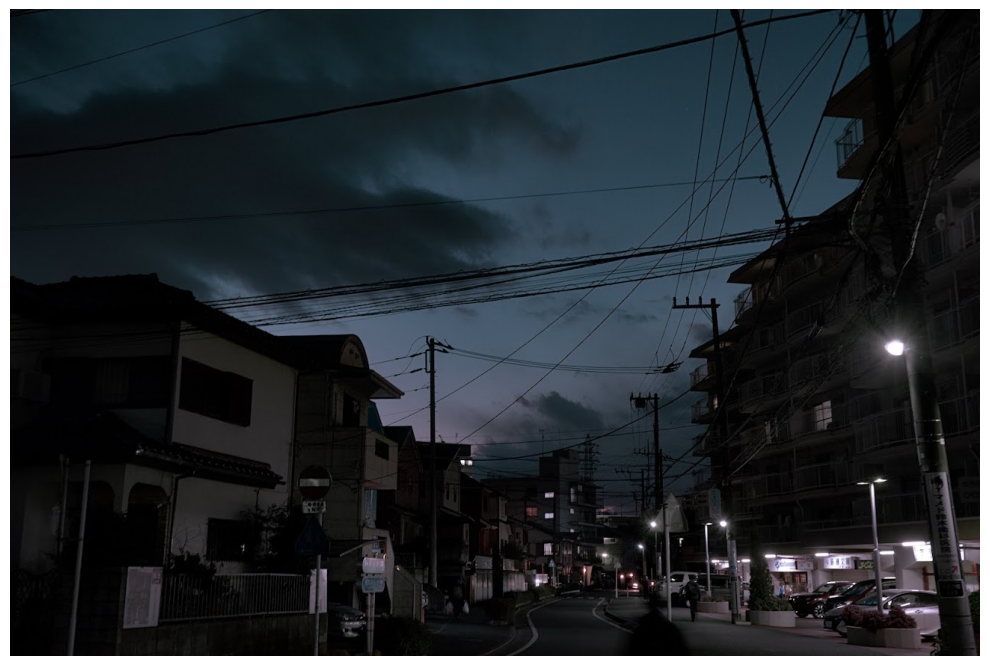

In [102]:
img = cv2.imread(imgPath)  # Read image from path / Leer imagen desde la ruta
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR (OpenCV) to RGB (matplotlib) / Convertir BGR (OpenCV) a RGB (matplotlib)

(h, w) = img.shape[:2]  # Get image height and width / Obtener alto y ancho de la imagen

comparisonGraphic(img, None)  # Show original image alone / Mostrar solo la imagen original

## Show comparison
### *Mostrar comparación*

### Flip
#### *Volteo / Espejado*

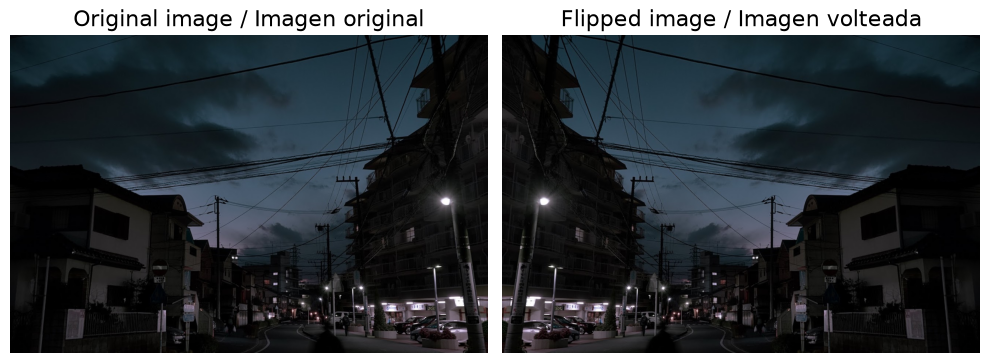

6945

In [103]:
img_flip = cv2.flip(img, 1)  # 1 for horizontal, 0 for vertical / 1 para horizontal, 0 para vertical

comparisonGraphic(img, img_flip, "Original image / Imagen original", "Flipped image / Imagen volteada")  # Compare original vs flipped / Comparar original con volteada

del img_flip  # Delete variables to free memory / Eliminar variable para liberar memoria
gc.collect()  # Force garbage collector / Forzar el recolector de basura

### Rotation
#### *Rotación*

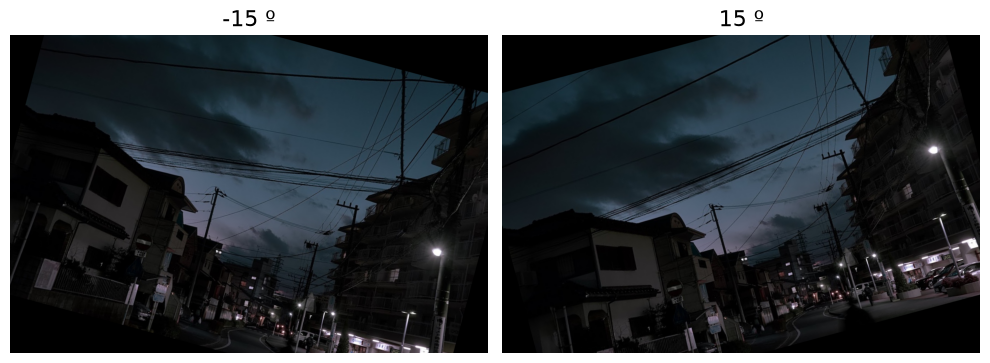

5059

In [104]:
angles = [-15, 15]  # Rotation angles in degrees / Ángulos de rotación en grados

center = (w // 2, h // 2)  # Image center / Centro de la imagen

M_rotate = cv2.getRotationMatrix2D(center, angles[0], 1.0)  # Build rotation matrix for first angle / Construir matriz de rotación para el primer ángulo
img_rotate = cv2.warpAffine(img, M_rotate, (w, h))  # Apply rotation to image / Aplicar rotación a la imagen

M_rotate2 = cv2.getRotationMatrix2D(center, angles[1], 1.0)  # Build rotation matrix for second angle / Construir matriz de rotación para el segundo ángulo
img_rotate2 = cv2.warpAffine(img, M_rotate2, (w, h))  # Apply rotation to image / Aplicar rotación a la imagen

comparisonGraphic(img_rotate, img_rotate2, f"{angles[0]} º", f"{angles[1]} º")  # Compare both rotations / Comparar ambas rotaciones

del angles, center, M_rotate, M_rotate2, img_rotate, img_rotate2  # Delete variables to free memory / Eliminar variables para liberar memoria
gc.collect()  # Force garbage collector / Forzar el recolector de basura

### Translation
#### *Traslación*

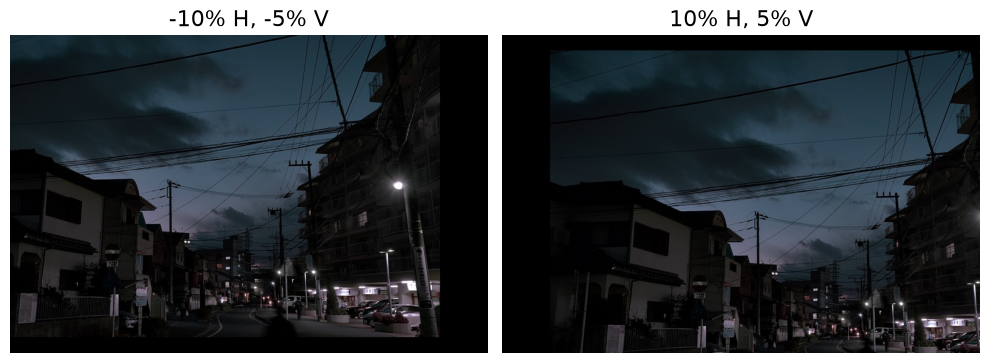

5063

In [105]:
PCT_H1 = -0.10  # -10% of width / -10% del ancho
PCT_V1 = -0.05  # -5% of height / -5% del alto

PCT_H2 = 0.10   # +10% of width / +10% del ancho
PCT_V2 = 0.05   # +5% of height / +5% del alto

px_horizontal1 = int(w * PCT_H1)  # Compute horizontal pixel offset 1 / Calcular desplazamiento horizontal en píxeles 1
px_vertical1 = int(h * PCT_V1)  # Compute vertical pixel offset 1 / Calcular desplazamiento vertical en píxeles 1

px_horizontal2 = int(w * PCT_H2)  # Compute horizontal pixel offset 2 / Calcular desplazamiento horizontal en píxeles 2
px_vertical2 = int(h * PCT_V2)  # Compute vertical pixel offset 2 / Calcular desplazamiento vertical en píxeles 2

M_translate1 = np.float32([[1, 0, px_horizontal1], [0, 1, px_vertical1]])  # Build translation matrix 1 / Construir matriz de traslación 1
img_translate1 = cv2.warpAffine(img, M_translate1, (w, h))  # Apply translation to image / Aplicar traslación a la imagen

M_translate2 = np.float32([[1, 0, px_horizontal2], [0, 1, px_vertical2]])  # Build translation matrix 2 / Construir matriz de traslación 2
img_translate2 = cv2.warpAffine(img, M_translate2, (w, h))  # Apply translation to image / Aplicar traslación a la imagen

comparisonGraphic(img_translate1, img_translate2, f'{PCT_H1*100:.0f}% H, {PCT_V1*100:.0f}% V', f'{PCT_H2*100:.0f}% H, {PCT_V2*100:.0f}% V')  # Compare both translations / Comparar ambas traslaciones

del PCT_H1, PCT_H2, PCT_V1, PCT_V2, px_horizontal1, px_vertical1, px_horizontal2, px_vertical2, M_translate1, M_translate2, img_translate1, img_translate2  # Delete variables to free memory / Eliminar variables para liberar memoria
gc.collect()  # Force garbage collector / Forzar el recolector de basura

### Scale factor
#### *Factor de escala*

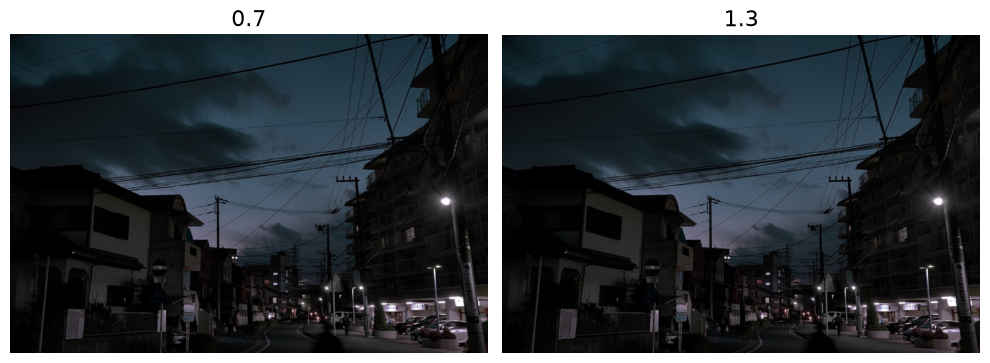

4757

In [106]:
scale_factor = [0.7, 1.3]  # Scale factors / Factores de escala

new_width = int(w * scale_factor[0])  # New width for first scale / Nuevo ancho para primera escala
new_height = int(h * scale_factor[0])  # New height for first scale / Nuevo alto para primera escala

new_width2 = int(w * scale_factor[1])  # New width for second scale / Nuevo ancho para segunda escala
new_height2 = int(h * scale_factor[1])  # New height for second scale / Nuevo alto para segunda escala

img_scaled = cv2.resize(img, (new_width, new_height))  # Resize image with first factor / Redimensionar imagen con primer factor
img_scaled2 = cv2.resize(img, (new_width2, new_height2))  # Resize image with second factor / Redimensionar imagen con segundo factor

comparisonGraphic(img_scaled, img_scaled2, f"{scale_factor[0]}", f"{scale_factor[1]}")  # Compare both scales / Comparar ambas escalas

del scale_factor, new_width, new_height, new_width2, new_height2, img_scaled, img_scaled2  # Delete variables to free memory / Eliminar variables para liberar memoria
gc.collect()  # Force garbage collector / Forzar el recolector de basura

### Cropping
#### *Recorte*

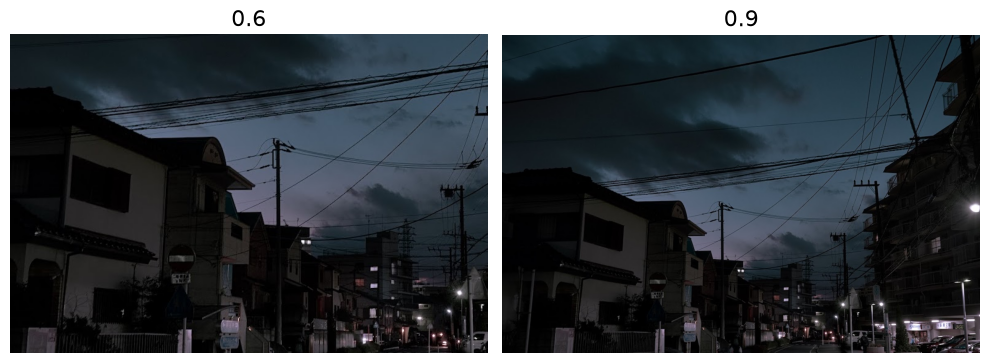

4900

In [107]:
crop_percent = [0.6, 0.9]  # Crop percentages / Porcentajes de recorte

crop_h = int(h * crop_percent[0])  # Crop height for first crop / Alto del recorte para el primer recorte
crop_w = int(w * crop_percent[0])  # Crop width for first crop / Ancho del recorte para el primer recorte

crop_h2 = int(h * crop_percent[1])  # Crop height for second crop / Alto del recorte para el segundo recorte
crop_w2 = int(w * crop_percent[1])  # Crop width for second crop / Ancho del recorte para el segundo recorte

start_x = np.random.randint(0, w - crop_w)  # Random starting X for first crop / X inicial aleatoria para el primer recorte
start_y = np.random.randint(0, h - crop_h)  # Random starting Y for first crop / Y inicial aleatoria para el primer recorte

start_x2 = np.random.randint(0, w - crop_w2)  # Random starting X for second crop / X inicial aleatoria para el segundo recorte
start_y2 = np.random.randint(0, h - crop_h2)  # Random starting Y for second crop / Y inicial aleatoria para el segundo recorte

img_crop = img[start_y:start_y+crop_h, start_x:start_x+crop_w]  # Crop first region / Recortar primera región
img_crop2 = img[start_y2:start_y2+crop_h2, start_x2:start_x2+crop_w2]  # Crop second region / Recortar segunda región

comparisonGraphic(img_crop, img_crop2, f"{crop_percent[0]}", f"{crop_percent[1]}")  # Compare both crops / Comparar ambos recortes

del crop_percent, crop_h, crop_w, crop_h2, crop_w2, start_x, start_y, start_x2, start_y2, img_crop, img_crop2  # Delete variables to free memory / Eliminar variables para liberar memoria
gc.collect()  # Force garbage collector / Forzar el recolector de basura

### Brightness and contrast
#### *Brillo y contraste*

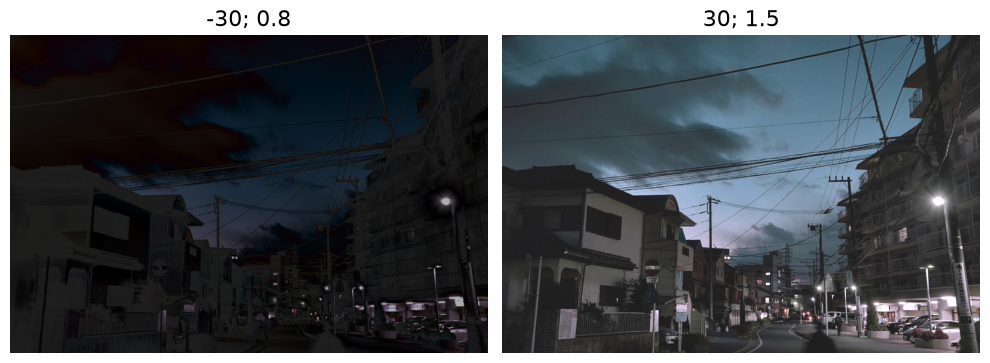

5320

In [108]:
alpha = [0.8, 1.5]  # Contrast (1.0 = original) / Contraste (1.0 = original)
beta = [-30, 30]    # Brightness (0 = original) / Brillo (0 = original)

img_brightness = cv2.convertScaleAbs(img, alpha=alpha[0], beta=beta[0])  # Apply first brightness/contrast / Aplicar primer brillo/contraste
img_brightness2 = cv2.convertScaleAbs(img, alpha=alpha[1], beta=beta[1])  # Apply second brightness/contrast / Aplicar segundo brillo/contraste

comparisonGraphic(img_brightness, img_brightness2, f'{beta[0]}; {alpha[0]}', f'{beta[1]}; {alpha[1]}')  # Compare both brightness/contrast settings / Comparar ambas configuraciones de brillo/contraste

del alpha, beta, img_brightness, img_brightness2  # Delete variables to free memory / Eliminar variables para liberar memoria
gc.collect()  # Force garbage collector / Forzar el recolector de basura


### Gaussian noise
#### *Ruido gaussiano*

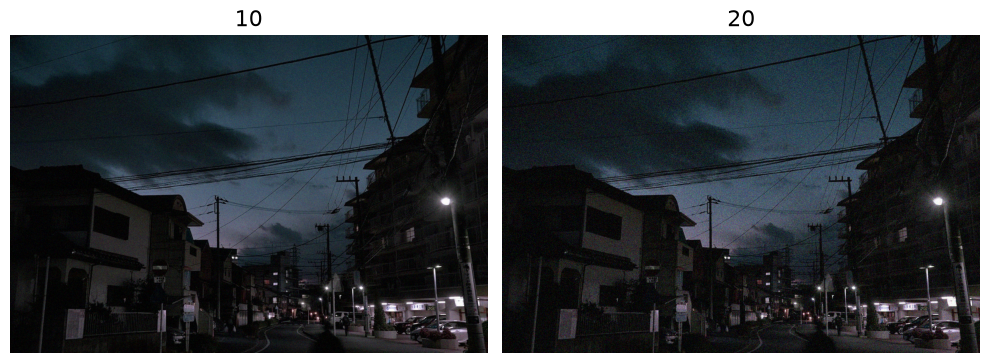

5031

In [109]:
mean = 0  # Noise mean / Media del ruido
sigma = [10, 20]  # Noise standard deviations / Desviaciones estándar del ruido

gaussian_noise = np.random.normal(mean, sigma[0], img.shape)  # Generate first Gaussian noise / Generar primer ruido gaussiano
gaussian_noise2 = np.random.normal(mean, sigma[1], img.shape)  # Generate second Gaussian noise / Generar segundo ruido gaussiano

img_noise = np.clip(img.astype(float) + gaussian_noise, 0, 255).astype(np.uint8)  # Add noise and clip to [0,255] / Añadir ruido y limitar a [0,255]
img_noise2 = np.clip(img.astype(float) + gaussian_noise2, 0, 255).astype(np.uint8)  # Add noise and clip to [0,255] / Añadir ruido y limitar a [0,255]

comparisonGraphic(img_noise, img_noise2, f'{sigma[0]}', f'{sigma[1]}')  # Compare both noise levels / Comparar ambos niveles de ruido

del mean, sigma, gaussian_noise, gaussian_noise2, img_noise, img_noise2  # Delete variables to free memory / Eliminar variables para liberar memoria
gc.collect()  # Force garbage collector / Forzar el recolector de basura